In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from cns.data_utils import load_pcawg

# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
pcawg = load_pcawg()
pcawg.cns["length"] = pcawg.cns["end"] - pcawg.cns["start"] + 1
pcawg.cns["total_cn"] = pcawg.cns["major_cn"] + pcawg.cns["minor_cn"]
pcawg.cns.head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,total_cn
0,SP1003,chr1,0,37828027,2,2,37828028,4
1,SP1003,chr1,37828027,38563006,2,1,734980,3
2,SP1003,chr1,38563006,39884821,2,0,1321816,2
3,SP1003,chr1,39884821,40536570,16,14,651750,30
4,SP1003,chr1,40536570,104039773,2,1,63503204,3


In [9]:
sample_cns = pcawg.cns.query("sample_id == 'SP1003'")
sample_cns.head()

,sample_id,chrom,start,end,major_cn,minor_cn,length,total_cn
0,SP1003,chr1,0,37828027,2,2,37828028,4
1,SP1003,chr1,37828027,38563006,2,1,734980,3
2,SP1003,chr1,38563006,39884821,2,0,1321816,2
3,SP1003,chr1,39884821,40536570,16,14,651750,30
4,SP1003,chr1,40536570,104039773,2,1,63503204,3


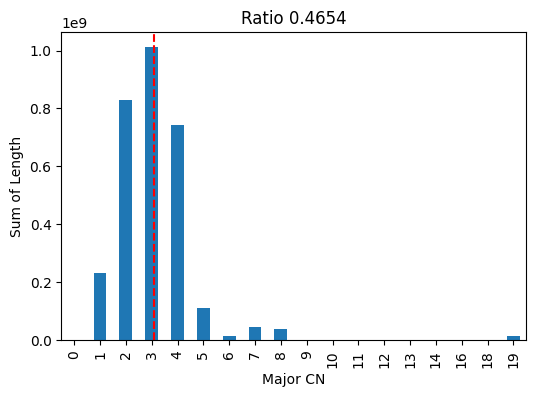

In [22]:
# Group by major_cn and sum the length
grouped = sample_cns.groupby('total_cn')['length'].sum()

# calculate weighted mean of total_cn
weighted_mean = np.average(grouped.index, weights=grouped.values)

# print a vertical line at the weighted mean
plt.axvline(x=weighted_mean, color='red', linestyle='--')

# calculate the sum of lengthgs below and above mean
below = grouped[grouped.index < weighted_mean].sum()
above = grouped[grouped.index > weighted_mean].sum()
ratio = above / below

# Create a bar plot
grouped.plot(kind='bar', figsize=(6, 4))

plt.xlabel('Major CN')
plt.ylabel('Sum of Length')
plt.title(f'Ratio {ratio:.4f}')
plt.show()

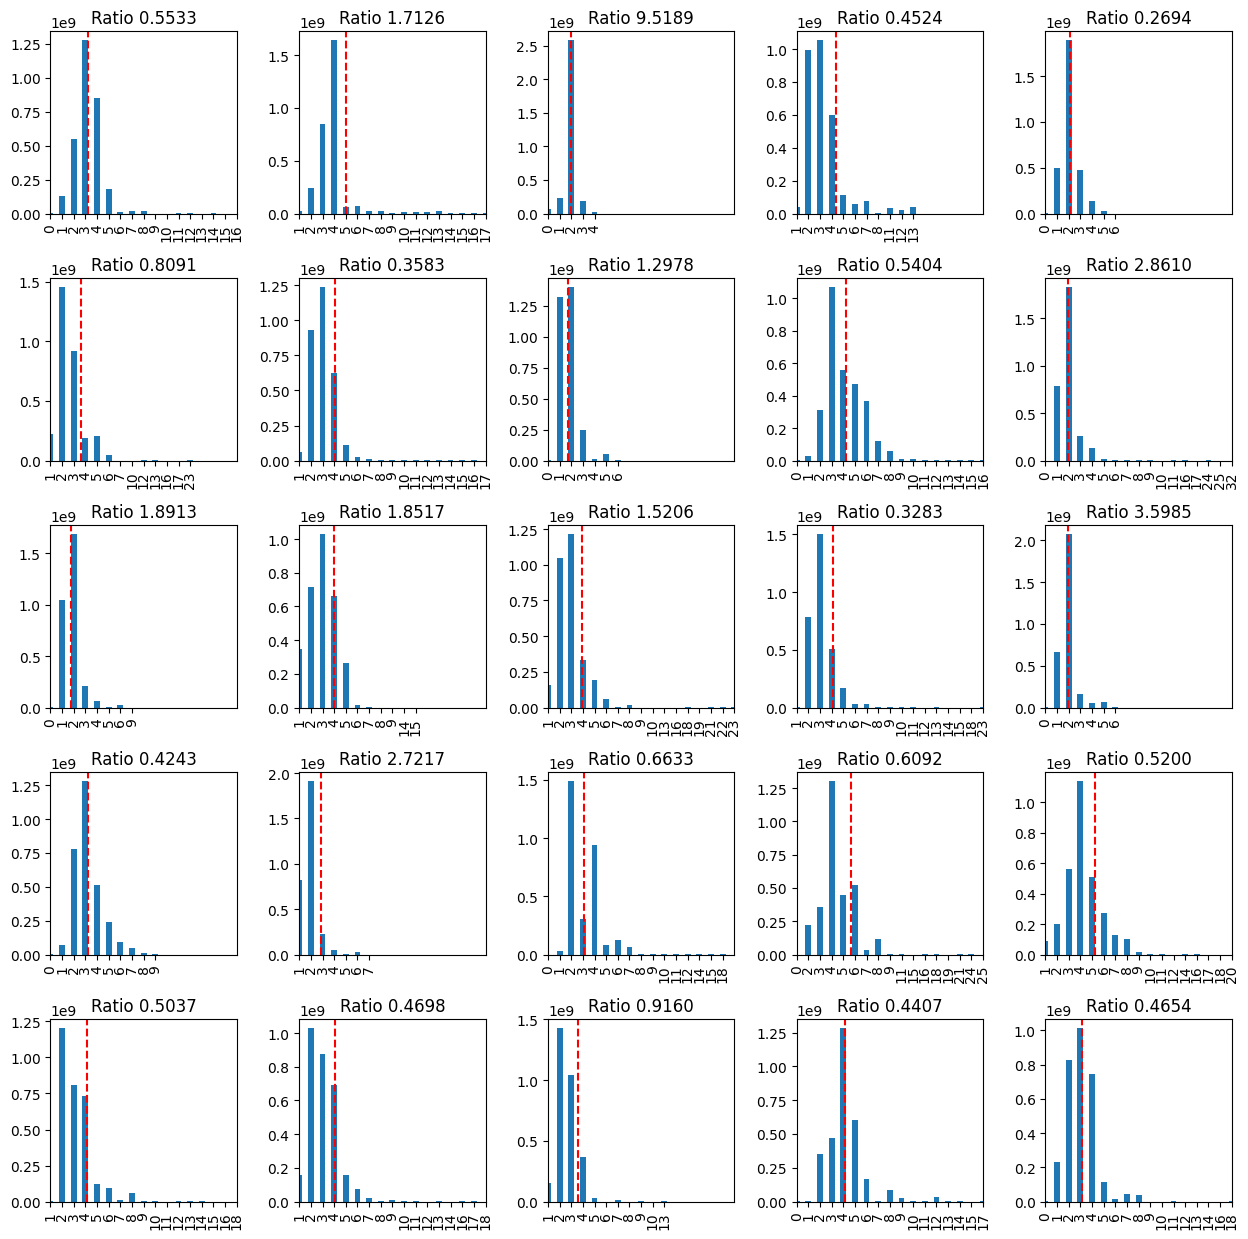

In [19]:
# create a 5 * 5 plot
fig, ax = plt.subplots(5, 5, figsize=(12.5, 12.5))

sample_ids = pcawg.cns["sample_id"].unique().tolist()

for x in range(5):
    for y in range(5):
        sample_id = sample_ids[x * 5 + y]
        sample_cns = pcawg.cns.query("sample_id == @sample_id")
        grouped = sample_cns.groupby('total_cn')['length'].sum()
        
        weighted_mean = np.average(grouped.index, weights=grouped.values)
        # print a vertical line at the weighted mean
        grouped.plot(kind='bar', ax=ax[x, y])

        below = grouped[grouped.index < weighted_mean].sum()
        above = grouped[grouped.index > weighted_mean].sum()
        ratio = above / below

        ax[x, y].axvline(x=weighted_mean, color='red', linestyle='--')
        ax[x, y].set_title(f'Ratio {ratio:.4f}')
        ax[x, y].set_xlim(0, 16)
        ax[x, y].set_xlabel("")

fig.tight_layout()

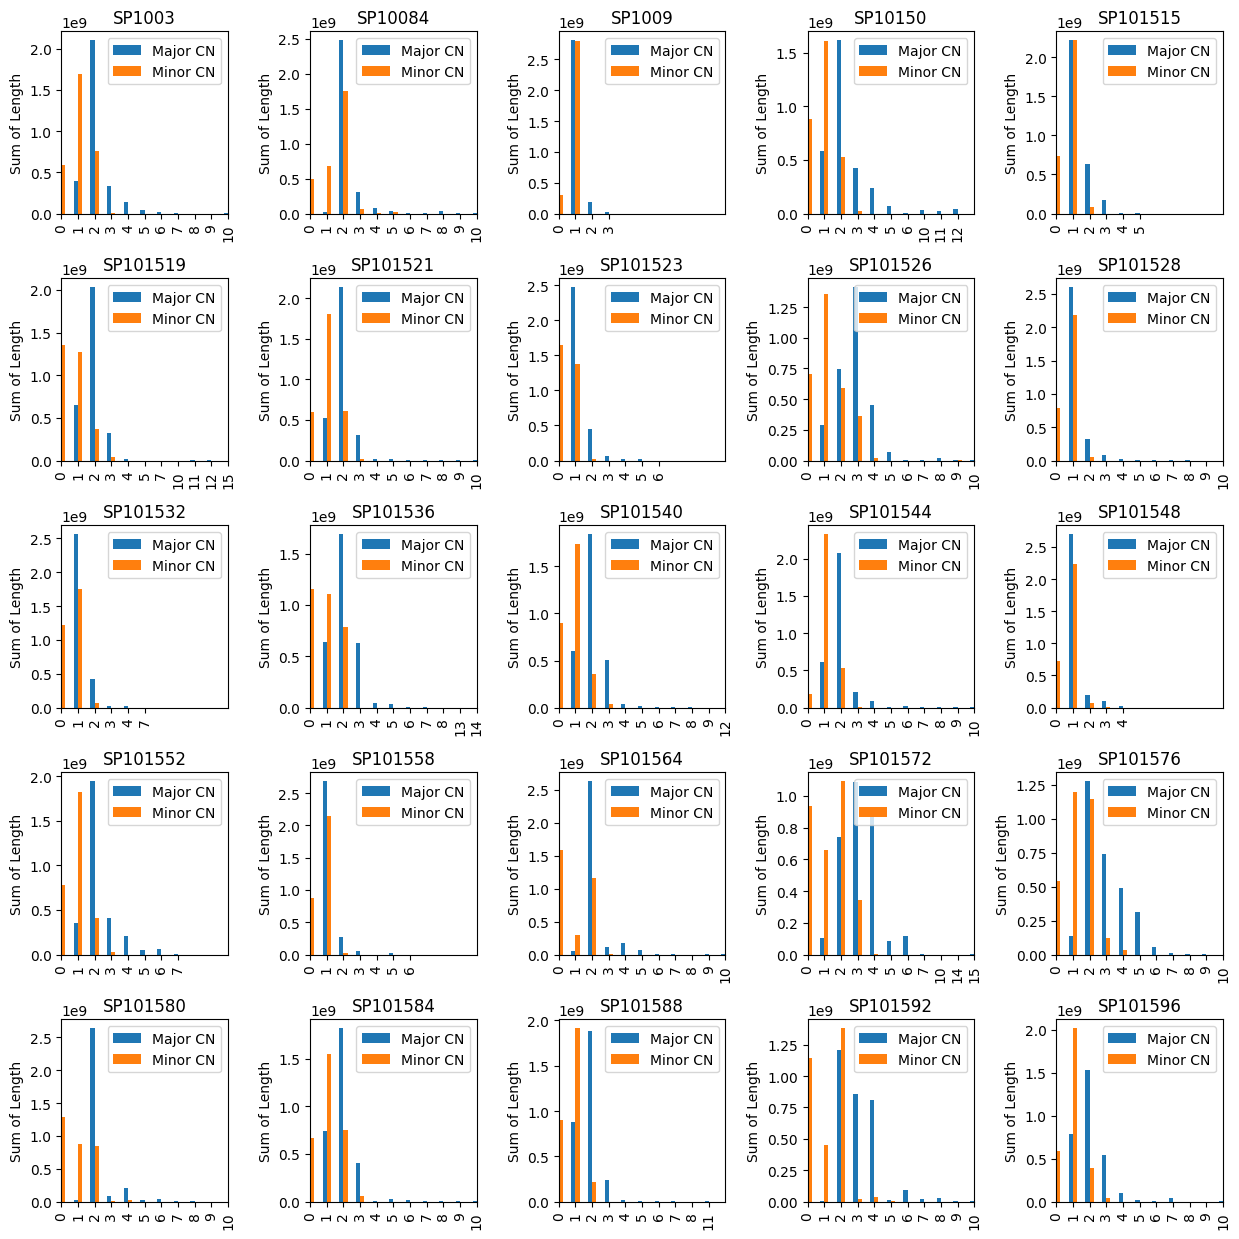

In [21]:
# create a 5 * 5 plot
fig, ax = plt.subplots(5, 5, figsize=(12.5, 12.5))

sample_ids = pcawg.cns["sample_id"].unique().tolist()

for x in range(5):
    for y in range(5):
        sample_id = sample_ids[x * 5 + y]
        sample_cns = pcawg.cns.query("sample_id == @sample_id")
        grouped = sample_cns.groupby('major_cn')['length'].sum()
        ax_sel = ax[x, y]

        # Group by major_cn and minor_cn and sum the length
        grouped_major = sample_cns.groupby('major_cn')['length'].sum()
        grouped_minor = sample_cns.groupby('minor_cn')['length'].sum()

        # Create a DataFrame from the grouped data
        df = pd.DataFrame({'Major CN': grouped_major, 'Minor CN': grouped_minor})

        # Fill NaN values with 0
        df.fillna(0, inplace=True)

        # Create a bar plot
        df.plot(kind='bar', ax=ax_sel)
        ax_sel.set_xlim(0, 10)
        ax_sel.set_xlabel("")
        ax_sel.set_ylabel('Sum of Length')
        ax_sel.set_title(sample_id)

fig.tight_layout()